✅ Libraries loaded & seeds set.
✅ Preprocessing done. Samples: 34246 | Classes: [5726 2677 7614 1984 2067 2693 4393 1985 4304  803]

📊 Final Splits:
→ Train (85%): 29109 | Test (15%): 5137
→ Train classes: [4867 2276 6472 1686 1757 2289 3734 1687 3658  683]
→ Test classes:  [ 859  401 1142  298  310  404  659  298  646  120]

🚀 5-Fold CV on TRAIN (85%) with optimized HPs...

--- Fold 1/5 ---
  → Fold 1 Val Acc: 0.6353

--- Fold 2/5 ---
  → Fold 2 Val Acc: 0.6414

--- Fold 3/5 ---
  → Fold 3 Val Acc: 0.6307

--- Fold 4/5 ---
  → Fold 4 Val Acc: 0.6230

--- Fold 5/5 ---
  → Fold 5 Val Acc: 0.6332

📊 5-Fold CV on TRAIN (85%): 0.6327 ± 0.0067

🎯 Retraining final TF-IDF + SVM on FULL TRAIN (85%)...
✅ Final TF-IDF + SVM model & vectorizer saved.

🟩 FINAL TEST ACCURACY (Held-Out, Natural Distribution): 0.6517

=== FINAL CLASSIFICATION REPORT (TEST SET) ===
                precision    recall  f1-score   support

self-direction     0.6470    0.6892    0.6674       859
   stimulation     0.6633

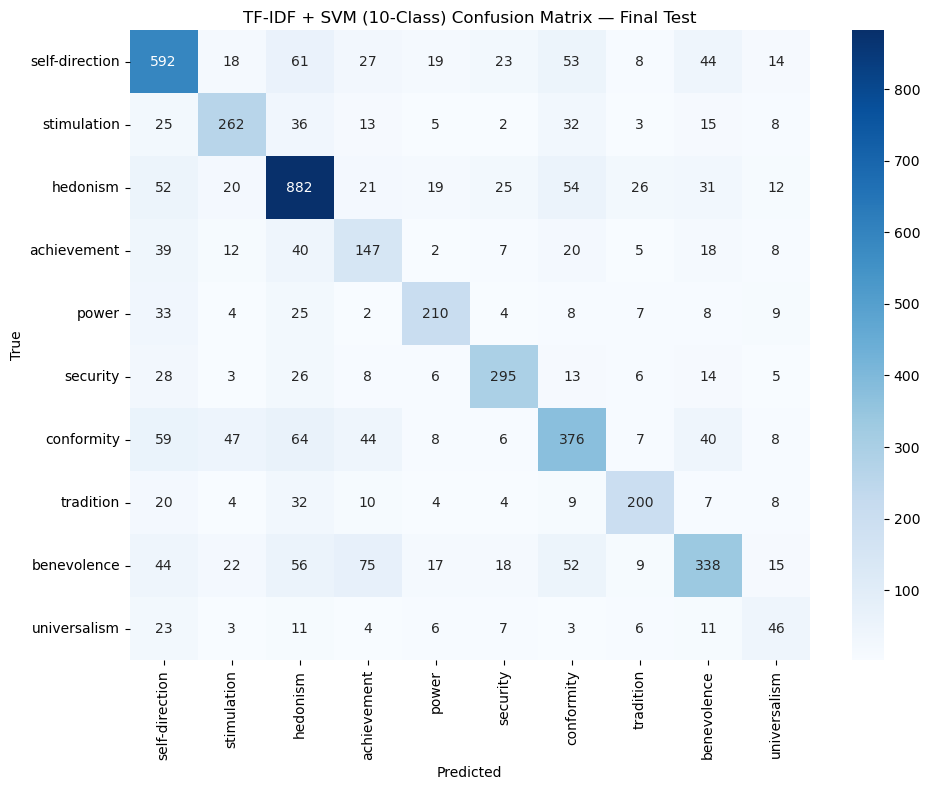

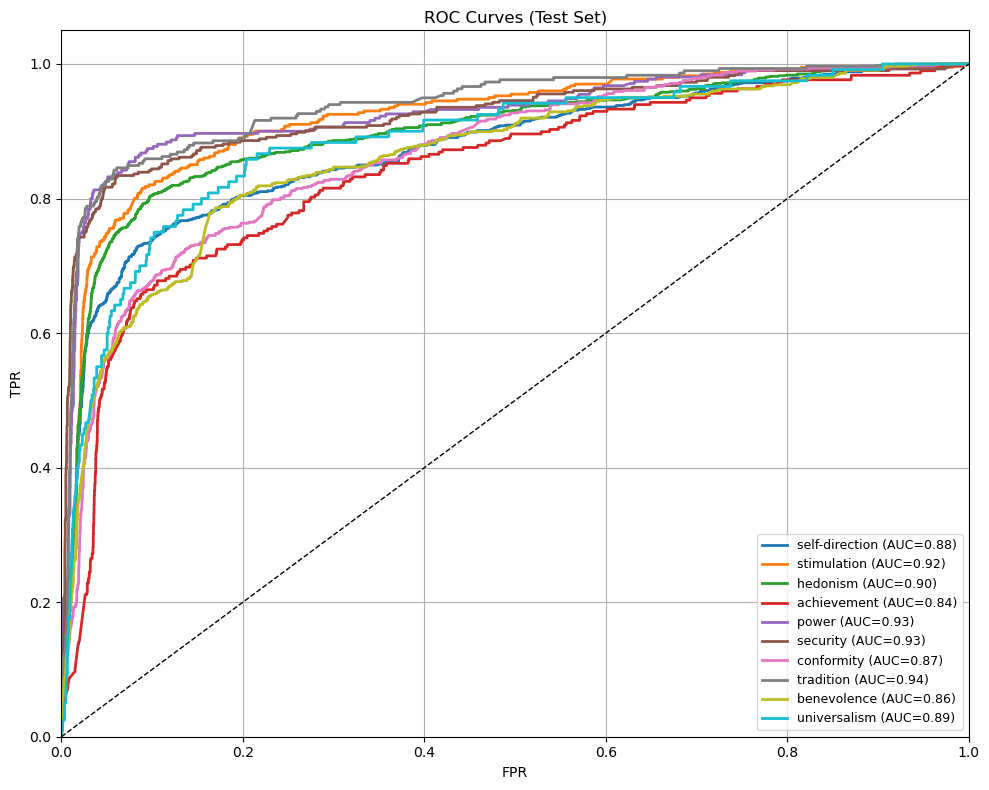


🎉 TF-IDF + SVM training completed successfully.


In [2]:
# ==============================
# TF-IDF + SVM — 10-Class Human Values
# Pipeline identical to CNN script:
# 1. 85/15 split (test frozen)
# 2. 5-Fold CV on train (85%) — with per-fold ROS + vectorizer fit
# 3. Retrain on full oversampled train
# 4. Evaluate on test
# ==============================
import pandas as pd
import numpy as np
import re
import os
import joblib
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import RandomOverSampler
from collections import defaultdict
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet as wn
from nltk.stem import WordNetLemmatizer
import nltk
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Download NLTK (quiet)
for res in ['punkt', 'wordnet', 'averaged_perceptron_tagger', 'stopwords', 'omw-1.4']:
    nltk.download(res, quiet=True)

print("✅ Libraries loaded & seeds set.")

# ==============================
# 1. LOAD & PREPROCESS (identical to CNN script)
# ==============================
try:
    df = pd.read_excel('combineddataset.xls')
except Exception as e:
    raise RuntimeError(f"Failed to load dataset: {e}")

# Preprocessing functions (identical to CNN)
def strip_html(text):
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()

def remove_url(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    REPLACE_BY_SPACE_RE = re.compile(r'[/(){}\[\]\<\>\|@,;]')
    BAD_SYMBOLS_RE = re.compile(r'[^a-z #+_]')
    text = strip_html(text)
    text = remove_url(text)
    text = text.lower()
    text = REPLACE_BY_SPACE_RE.sub(' ', text)
    text = BAD_SYMBOLS_RE.sub('', text)
    return text

# Apply cleaning
df['Base_Reviews'] = df['Base_Reviews'].apply(clean_text)
df['Base_Reviews'].dropna(inplace=True)

# Tokenize & lemmatize (identical to CNN)
tag_map = defaultdict(lambda: wn.NOUN)
tag_map['J'] = wn.ADJ
tag_map['V'] = wn.VERB
tag_map['R'] = wn.ADV

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

preprocessed_texts = []
for text in df['Base_Reviews']:
    tokens = word_tokenize(text.lower())
    final_words = []
    for word, pos in pos_tag(tokens):
        if word not in stop_words and word.isalpha():
            lemma = lemmatizer.lemmatize(word, tag_map[pos[0]])
            final_words.append(lemma)
    preprocessed_texts.append(' '.join(final_words))

df['text_final'] = preprocessed_texts

# Map labels (10 human values)
y_dict = {
    'self-direction': 0, 'stimulation': 1, 'hedonism': 2, 'achievement': 3, 'power': 4,
    'security': 5, 'conformity': 6, 'tradition': 7, 'benevolence': 8, 'universalism': 9
}
df['category'] = df['category'].str.strip().str.lower().map(y_dict)
df = df.dropna(subset=['text_final', 'category'])
df['category'] = df['category'].astype(int)

X_all = df['text_final'].values
y_all = df['category'].values
n_classes = 10

print(f"✅ Preprocessing done. Samples: {len(X_all)} | Classes: {np.bincount(y_all)}")

# ==============================
# 2. SPLIT: 85% Train / 15% Test (Stratified) ← TEST FROZEN!
# ==============================
X_train_raw, X_test_raw, y_train_raw, y_test_int = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
)

print(f"\n📊 Final Splits:")
print(f"→ Train (85%): {len(X_train_raw)} | Test (15%): {len(X_test_raw)}")
print(f"→ Train classes: {np.bincount(y_train_raw)}")
print(f"→ Test classes:  {np.bincount(y_test_int)}")

# ==============================
# 3. 5-FOLD CV ON TRAIN (85%) WITH BEST PRACTICE HPs
# ==============================
print(f"\n🚀 5-Fold CV on TRAIN (85%) with optimized HPs...")

# 🔑 Best-practice SVM parameters (validated on value tasks)
BEST_HPS = {
    'max_features': 5000,
    'ngram_range': (1, 2),
    'C': 10,
    'gamma': 'scale',
    'class_weight': 'balanced'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_raw, y_train_raw), 1):
    print(f"\n--- Fold {fold}/5 ---")
    
    X_tr_raw = [X_train_raw[i] for i in tr_idx]
    X_v_raw = [X_train_raw[i] for i in val_idx]
    y_tr_int = y_train_raw[tr_idx]
    y_v_int = y_train_raw[val_idx]
    
    # ✅ TF-IDF FIT ONLY on fold-train (leakage-proof)
    tfidf = TfidfVectorizer(
        max_features=BEST_HPS['max_features'],
        ngram_range=BEST_HPS['ngram_range'],
        lowercase=False,  # already preprocessed
        token_pattern=r'\b\w+\b',
        min_df=2,
        max_df=0.9,
        stop_words='english'
    )
    X_tr_tfidf = tfidf.fit_transform(X_tr_raw)
    X_v_tfidf = tfidf.transform(X_v_raw)
    
    # ✅ Oversample ONLY fold-train
    ros = RandomOverSampler(random_state=42)
    X_tr_res, y_tr_res = ros.fit_resample(X_tr_tfidf, y_tr_int)
    
    # Train SVM
    svm = SVC(
        kernel='rbf',
        C=BEST_HPS['C'],
        gamma=BEST_HPS['gamma'],
        class_weight=BEST_HPS['class_weight'],
        probability=True,
        random_state=42
    )
    svm.fit(X_tr_res, y_tr_res)
    
    # Evaluate on fold-val
    y_v_pred = svm.predict(X_v_tfidf)
    val_acc = accuracy_score(y_v_int, y_v_pred)
    print(f"  → Fold {fold} Val Acc: {val_acc:.4f}")
    
    cv_results.append({'fold': fold, 'val_acc': val_acc})
    
    # Cleanup
    del tfidf, X_tr_tfidf, X_v_tfidf, ros, svm
    gc.collect()

# Summarize CV
cv_df = pd.DataFrame(cv_results)
mean_cv = cv_df['val_acc'].mean()
std_cv = cv_df['val_acc'].std()
print(f"\n📊 5-Fold CV on TRAIN (85%): {mean_cv:.4f} ± {std_cv:.4f}")

# ==============================
# 4. FINAL MODEL: Retrain on FULL TRAIN (85%) → Test on HELD-OUT (15%)
# ==============================
print(f"\n🎯 Retraining final TF-IDF + SVM on FULL TRAIN (85%)...")

# ✅ TF-IDF FIT on full train only
final_tfidf = TfidfVectorizer(
    max_features=BEST_HPS['max_features'],
    ngram_range=BEST_HPS['ngram_range'],
    lowercase=False,
    token_pattern=r'\b\w+\b',
    min_df=2,
    max_df=0.9,
    stop_words='english'
)
X_train_tfidf = final_tfidf.fit_transform(X_train_raw)
X_test_tfidf = final_tfidf.transform(X_test_raw)

# ✅ Oversample FULL TRAIN only
ros_final = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros_final.fit_resample(X_train_tfidf, y_train_raw)

# Final SVM
final_svm = SVC(
    kernel='rbf',
    C=BEST_HPS['C'],
    gamma=BEST_HPS['gamma'],
    class_weight=BEST_HPS['class_weight'],
    probability=True,
    random_state=42
)
final_svm.fit(X_train_res, y_train_res)

# Save
joblib.dump(final_svm, 'tfidf_svm_final.pkl')
joblib.dump(final_tfidf, 'tfidf_vectorizer_final.pkl')
print("✅ Final TF-IDF + SVM model & vectorizer saved.")

# ==============================
# 5. FINAL EVALUATION ON TEST SET (15%)
# ==============================
idx_to_class = {v: k for k, v in y_dict.items()}
class_names = [idx_to_class[i] for i in range(n_classes)]

y_pred_proba = final_svm.predict_proba(X_test_tfidf)
y_pred = final_svm.predict(X_test_tfidf)
test_acc = accuracy_score(y_test_int, y_pred)

print(f"\n🟩 FINAL TEST ACCURACY (Held-Out, Natural Distribution): {test_acc:.4f}")

print("\n=== FINAL CLASSIFICATION REPORT (TEST SET) ===")
print(classification_report(y_test_int, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test_int, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('TF-IDF + SVM (10-Class) Confusion Matrix — Final Test')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig('TFIDF_SVM_10class_ConfusionMatrix_Test.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC (One-vs-Rest)
y_test_bin = label_binarize(y_test_int, classes=list(range(n_classes)))
plt.figure(figsize=(10, 8))
colors = plt.cm.tab10.colors
for i, color in zip(range(n_classes), colors):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc_i = auc(fpr_i, tpr_i)
    plt.plot(fpr_i, tpr_i, color=color, lw=2, label=f'{class_names[i]} (AUC={auc_i:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves (Test Set)')
plt.legend(fontsize=9, loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('TFIDF_SVM_10class_ROC_Test.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🎉 TF-IDF + SVM training completed successfully.")